# <center>Project 2 2026</center>

<center>Author: Lewei Xu (23709058)</center>

In this project we work with monthly mean minimum and maximum temperature sequences recorded at weather stations in Western Australia. The training sequences come from Perth Airport, Jandakot Aero and Perth Metro, the validation sequences from Swanbourne, and the test sequences from Bickley. As a result, every model is trained on one group of stations and then tested on a station it has never seen. In this project we will:

1. Train a two-layered GRU network that forecasts the next 12 months in one go. (Section 2)
2. Train the same network to forecast 1 month, then run it in a loop to reach 12 months. (Section 3)
3. Train a GRU encoder-decoder that generates the 12 months autoregressively. (Section 4)
4. Compare the last two models as the prediction horizon grows from 12 to 24 months. (Section 5)
5. Train a variational autoencoder to synthesize maximum temperature sequences. (Section 6)

### Environment, Hardware, and Running the Notebook

This project was developed and run on the following setup, and the timings reported are specific to this hardware:

1. GPU: nvidia rtx 5070 12gb (blackwell 12.0)
2. CPU/RAM: Intel core ultra 7 265K, 20 cores, 64gb RAM
3. OS: Ubuntu on WSL2, NVIDIA driver 591.86
4. Software versions: Python 3.12.13, TensorFlow 2.21.0 (conda build CUDA 13.0), Keras 3.15.0

TensorFlow 2.21 was used instead of the specified 2.20 in the unit's yaml configuration due to incompatibility with rtx5070 sm_120 (TensorFlow 2.20 only works with sm_60 to sm_90). The code itself however should not be specific to hardware or environment, so as long as a compatible environment is installed, this notebook should run.

## Section 1: Setup and Data

In this section, we will load the .pkl file, checks the sequence lengths, split them into inputs and targets, and build the plotting function that will be reused in later sections.

### Section 1.1: Imports and Data Loading

First, we will make the necessary imports, set seed for reproducibility, and define some constants used throughout the project. ``INPUT_LENGTH`` and ``TARGET_LENGTH`` are the length of the input sequence and length of the predicted sequecne respectively. ``SCALE`` is the constant we divide temperatures by (see Section 2.1), and ``N_UNITS`` and ``LEARNING_RATE`` are the number of units in each GRU layer and the Nadam learning rate.

**NOTE:** all 3 GRU models in this project share the same hyperparameters: ``N_UNITS`` neurons per GRU layer, ``LEARNING_RATE``, Huber loss, the Nadam optimizer, ``tanh`` activation, and the same scaling constant. This is so that the comparison in Section 5 shows the difference between the architectures rather than the result of excessive tuning. At this learning rate, all 3 models are still improving slowly at epoch 100, so early stopping rarely occurs and mostly serves to restore the best epoch's weights.

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tf.keras.utils.set_random_seed(42)

INPUT_LENGTH = 72
TARGET_LENGTH = 12
SCALE = 40.

I0000 00:00:1790223601.846355  138801 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790223601.878122  138801 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Now we will load the pickle file with the function provided in the project specification.

In [2]:
def load_data(picklefile):
    import pickle
    f = open(picklefile, "rb")
    data = pickle.load(f)
    f.close()
    return data

train_seq, val_seq, test_seq = load_data("temperatures-2026.pkl")

print(f"train_seq: {train_seq.shape}  val_seq: {val_seq.shape}  test_seq: {test_seq.shape}")
print(f"type: {type(train_seq)}  dtype: {train_seq.dtype}")

train_seq: (1522, 84, 2)  val_seq: (313, 84, 2)  test_seq: (297, 96, 2)
type: <class 'tensorflow.python.framework.ops.EagerTensor'>  dtype: <dtype: 'float32'>


I0000 00:00:1790223604.922160  138801 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8376 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:02:00.0, compute capability: 12.0a


Here we can see that the shapes match the project spec. Before going further, lets do some simple data exploration.

In [3]:
sets = {"train": train_seq, "val": val_seq, "test": test_seq}
# Produce dataframe of statistics
pd.DataFrame({
    "sequences": [s.shape[0] for s in sets.values()],
    "months": [s.shape[1] for s in sets.values()],
    "mean min": [float(tf.reduce_mean(s[:, :, 0])) for s in sets.values()],
    "mean max": [float(tf.reduce_mean(s[:, :, 1])) for s in sets.values()],
    "lowest": [float(tf.reduce_min(s)) for s in sets.values()],
    "highest": [float(tf.reduce_max(s)) for s in sets.values()],
}, index=sets.keys()).round(2)

,sequences,months,mean min,mean max,lowest,highest
train,1522,84,12.23,24.70,3.8,36.3
val,313,84,14.04,24.11,7.6,34.0
test,297,96,11.32,22.63,5.3,33.8


Here we can see that every temperature in the data sits in the expected range of our regular perth weather (between 4-36C approximately). The minimum and maximum components are on the same scale, so we can treat them each as a two channel 1D image instead of 2 unrelated features when designing and training our VAE in section 6.

Additionally, the three sets show different climate. For example, Bickley, the test station is the coolest area at about 2 degrees below the training and validation mean. The sets also show different min/max temperatures, with the validation set having a comparitively higher min temperature. As such, every MAE reported in this project would be a transfer result, measured on a station whose climate no model was trained on. The validation and test set are not measuring the exact same kind of shifts as each other (although they would be similar as they are all in the same general geographic region).

### Section 1.2: Splitting the Sequences

We will now split the training and validation sequences into 72 months of input and 12 months of predictions. The test sequences are 96 months long, so the remaining 12 months of sequences are not used until section 5 when we compare the models in section 3 and 4.

In [4]:
def split_sequences(sequences, input_length=INPUT_LENGTH, target_length=TARGET_LENGTH):
    X = sequences[:, :input_length]
    y = sequences[:, input_length:input_length + target_length]
    return X, y

X_train, y_train = split_sequences(train_seq)
X_val, y_val = split_sequences(val_seq)
X_test, y_test = split_sequences(test_seq)

for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"{name}: X {X.shape}  y {y.shape}")

train: X (1522, 72, 2)  y (1522, 12, 2)
val: X (313, 72, 2)  y (313, 12, 2)
test: X (297, 72, 2)  y (297, 12, 2)


### Section 1.3: Visualising the Sequences

Finally, we will construct the ``display_temperatures`` function that samples 3 sequences at random, rejoins their input with its target, and plots the minimum and maximum series together. The dotted line marks where the forecast begins.

Two optional arguments allow this function to be reusable for later sections in this project. ``y_pred`` allows input of predictions over the target region as crosses and puts the prediction's MAE in the subplot title, and ``indices`` allows the function to display specific sequences instead of random ones.

In [5]:
def display_temperatures(X, y, title, y_pred=None, indices=None, n_seqs=3, seed=42):

    # Sample sequences at random unless specific indices were speified
    if indices is None:
        rng = np.random.default_rng(seed)
        indices = rng.choice(X.shape[0], size=n_seqs, replace=False)
    indices = np.asarray(indices)[:n_seqs]

    input_length = X.shape[1]
    months = np.arange(input_length + y.shape[1])
    future = months[input_length:]

    fig, axes = plt.subplots(1, len(indices), figsize=(16, 3.6), squeeze=False)
    for ax, index in zip(axes[0], indices):
        combined = tf.concat([X[index], y[index]], axis=0)
        ax.plot(months, combined[:, 0], color="tab:blue", label="minimum")
        ax.plot(months, combined[:, 1], color="tab:red", label="maximum")
        ax.axvline(input_length - 0.5, color="black", linestyle=":")

        subtitle = f"sequence {index}"
        if y_pred is not None:
            ax.plot(future, y_pred[index][:, 0], "x", color="tab:cyan", label="minimum predicted")
            ax.plot(future, y_pred[index][:, 1], "x", color="tab:orange", label="maximum predicted")
            subtitle += f", MAE {float(tf.reduce_mean(tf.abs(y[index] - y_pred[index]))):.2f}"

        ax.set_title(subtitle)
        ax.set_xlabel("month")
        ax.set_ylabel("temperature (C)")
        ax.grid(True)

    # One legend for whole figure
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(labels))
    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0.09, 1, 1])
    plt.show()

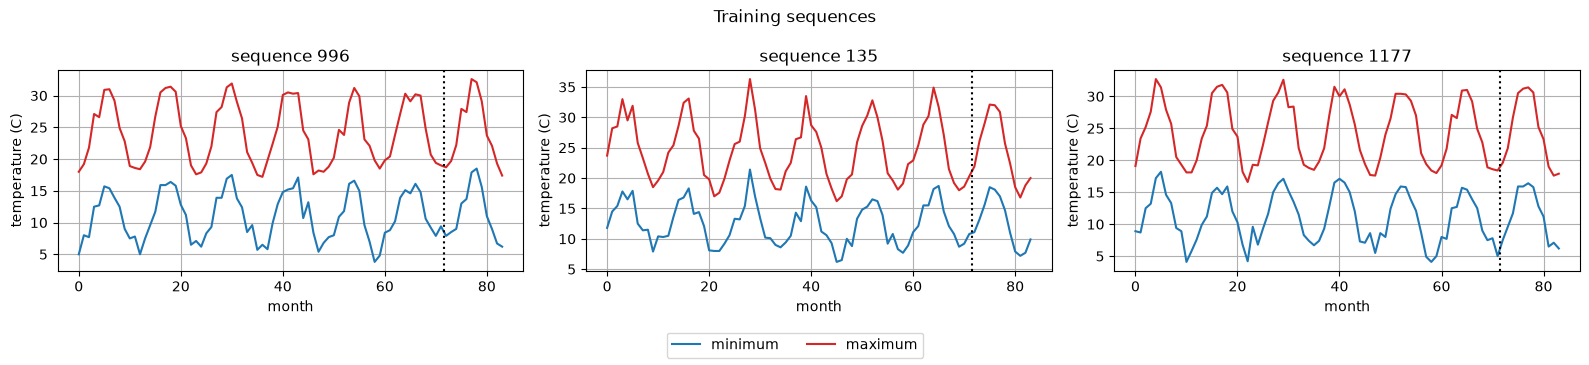

In [6]:
display_temperatures(X_train, y_train, "Training sequences")

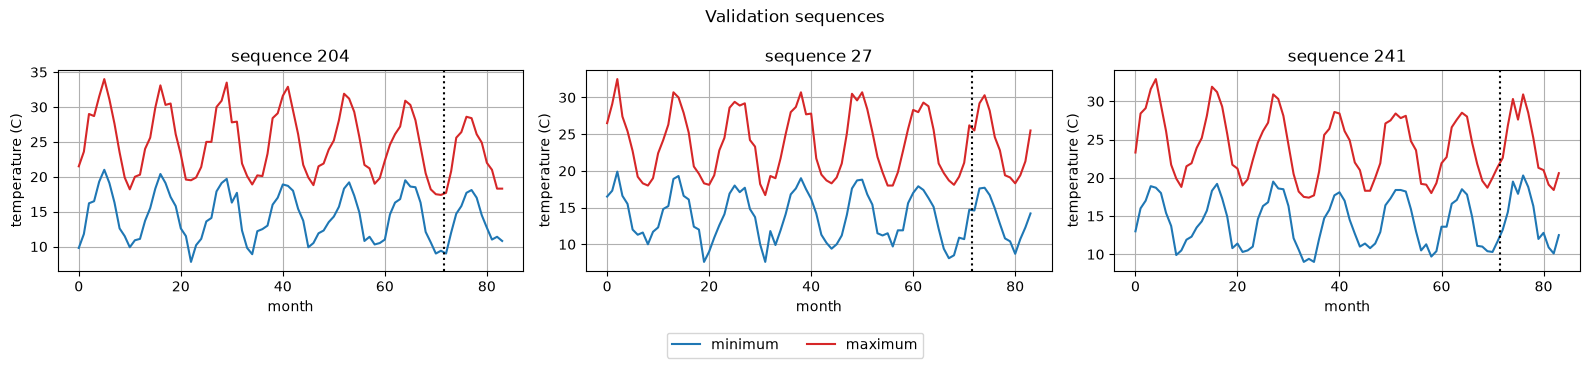

In [7]:
display_temperatures(X_val, y_val, "Validation sequences")

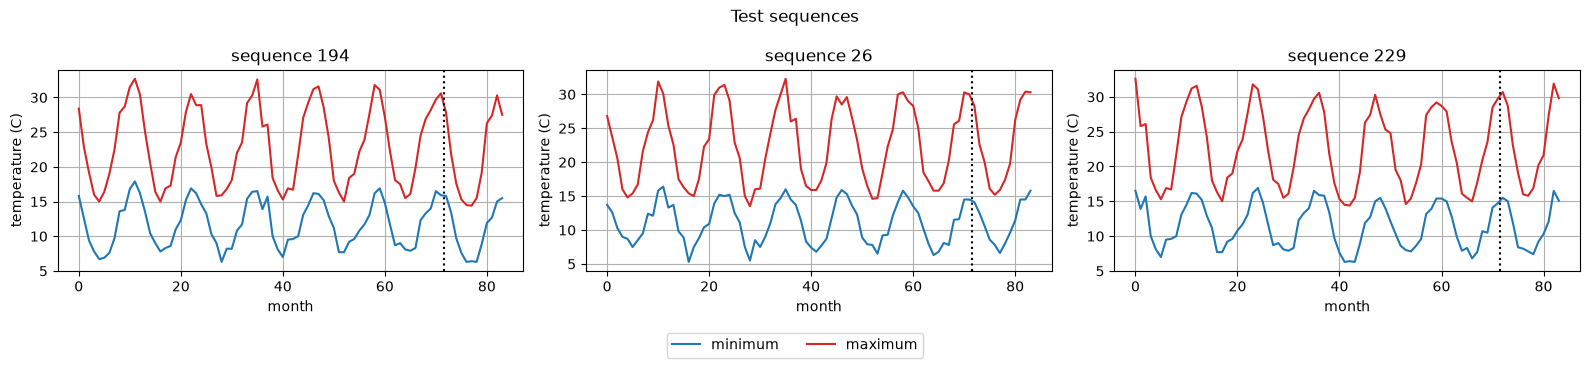

In [8]:
display_temperatures(X_test, y_test, "Test sequences")

In all three sets, we can see the same strong annual cycle (as expected), with the minimum and maxiumum series rising and falling together. Each 72 input months corresponds to 6 complete cycles (years), which should provide the model plenty of reptitions to learn the shape from. What may be difficult to predict however is the height/amplitude of the cycle rather than the actual shape.

## Section 2: Model 1, Direct 12-Month Forecast

In this section, we will implement a model to predict the following 12 months' mean minimum and maximum temperatures in one go.

### Section 2.1: Network Architecture

Model 1 consists of two GRU layers, each with 16 units, and a ``Dense`` layer with 24 outputs (corresponding to the 12 months of predictions for min and max temperatures respectively), then a ``Reshape`` layer to produce the final 12 by 2 target shape. Only the second GRU layer's final output is needed, so we use ``return_sequences=True`` only on the first GRU layer.

The problem with a GRU/RNN is that the default activation is ``tanh``, which squashes each layer's output to [-1, 1]. Our temperature values range from 4-36 degrees, so feeding these values straight into the network and asking the linear ``Dense`` layer to recover the degrees won't work very well. In this configuration, we found that the network settled at a fairly high test MAE at ~3.6 degrees which is even worse than just predicting a flat average:

In [9]:
train_mean = tf.reduce_mean(X_train, axis=[0, 1])
val_mean = tf.reduce_mean(X_val, axis=1, keepdims=True)
print(f"Flat training mean, validation MAE: {tf.reduce_mean(tf.abs(y_val - train_mean)):.2f} C")
print(f"Flat validation mean, validation MAE: {tf.reduce_mean(tf.abs(y_val - val_mean)):.2f} C")

Flat training mean, validation MAE: 3.56 C
Flat validation mean, validation MAE: 3.45 C


There are two solutions to this problem: either use ``relu`` activation, which leaves hidden states unbounded so that temperature values can pass straight through, or keep the default ``tanh`` and instead use scaling to put the data into the activation range. For the scaling solution, we used a constant ``Rescaling(1. / SCALE)`` (``SCALE = 40.`` defined in Section 1.1) which is just above the highest temperature in the data, putting every value into roughly 0.1 to 0.9. Through various testing and hyperparameter tuning, we found that using ``tanh`` with scaling and a learning rate of 0.005 produced slightly better results at 1.12 degrees MAE compared to 1.18 degrees MAE using ``relu``. Implemented below is the model using this setup.

We use a constant scaling factor which is the same thing as dividing image pixels by 255. The relationship between the minimum and maximum series, and between one month and the next, remains the same, and there is no per-feature standardisation of the kind the project specification warns against. The targets are divided by the same constant, and we scale the MAE Keras reports back up so that every number in this notebook is in degrees Celsius.

In [10]:
def mae_degrees(y_true, y_pred):
    # Multiply by SCALE to report the MAE in degrees
    return tf.reduce_mean(tf.abs(y_true - y_pred)) * SCALE

def build_gru_model(target_length, n_units=16, input_length=INPUT_LENGTH, learning_rate=0.005):
    tf.keras.utils.set_random_seed(42)

    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=[input_length, 2]),
        tf.keras.layers.Rescaling(1. / SCALE),
        tf.keras.layers.GRU(n_units, return_sequences=True),
        tf.keras.layers.GRU(n_units),
        tf.keras.layers.Dense(target_length * 2),
        tf.keras.layers.Reshape([target_length, 2]),
    ])
    model.compile(loss=tf.keras.losses.Huber(),
                  optimizer=tf.keras.optimizers.Nadam(learning_rate=learning_rate),
                  metrics=[mae_degrees])
    return model

model_1 = build_gru_model(TARGET_LENGTH)
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 72, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 72, 16)         │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 12, 2)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000 (11.72 KB)

 Trainable params: 3,000 (11.72 KB)

 Non-trainable params: 0 (0.00 B)

### Section 2.2: Training

Here we define three helper functions that can be reused across all 3 models. 

``train_model`` runs 100 epochs with early stopping on the validation MAE with ``restore_best_weights=True`` so the weights we use are the best ones seen so far. ``X`` can also be passed as a list to let this same function train the two input encoder-decoder in Section 4.

``plot_learning_curve`` plots two learning curves, one for loss and one for MAE. We separate loss and MAE as they are on different scales and not comparable with each other.

``forecast`` runs a model and undoes the target scaling so that reported numbers is in degrees.

In [11]:
def train_model(model, X, y, X_valid, y_valid, epochs=100, patience=15):
    # mode="min" is used to stop training when monitored quatity stops decreasing
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_mae_degrees", mode="min",
                                                      patience=patience, restore_best_weights=True)
    return model.fit(X, y, epochs=epochs, validation_data=(X_valid, y_valid), callbacks=[early_stopping], verbose=0)

def plot_learning_curve(history, title):
    curves = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    curves[["loss", "val_loss"]].plot(ax=axes[0], grid=True, xlabel="Epoch", ylabel="loss")
    curves[[c for c in curves.columns if "mae" in c]].plot(ax=axes[1], grid=True, xlabel="Epoch", ylabel="MAE (°C)")
    fig.suptitle(f"{title} ({len(curves)} epochs)")
    plt.tight_layout()
    plt.show()

def forecast(model, X):
    # Helper function to undo target scaling and forecast
    return model(X, training=False) * SCALE

Let's now train our first model and plot the learning curves. Note that because we use a Rescaling layer, the outputs of the network would similarly be scaled, so we scale the targets accordingly as well.

I0000 00:00:1790223608.273380  138891 cuda_dnn.cc:461] Loaded cuDNN version 92301


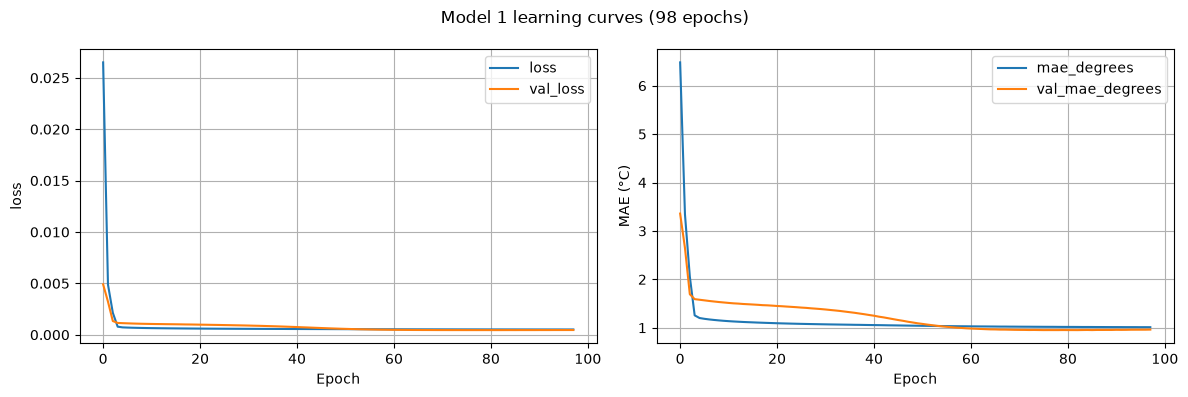

In [12]:
y_train_scaled = y_train / SCALE
y_val_scaled = y_val / SCALE

# Reseed before each training run so the result does not depend on the preceding cells
tf.keras.utils.set_random_seed(42)

history_1 = train_model(model_1, X_train, y_train_scaled, X_val, y_val_scaled)
plot_learning_curve(history_1, "Model 1 learning curves")

Here we can see that training went quite well. Both curves drop almost vertically over the first two or three epochs, from an MAE of about 6.5 degrees down to roughly 1.3. Everything after that is a long slow grind from 1.3 to just under 1.0 spread over the remaining 90-ish epochs. The validation MAE sits above the training MAE until about epoch 55 and then crosses below it, indicating that overfitting did not occur and the model generalises well. This may be because the training sequences came from 3 different stations compared to just one station for the validation set. From the plot, training reached about 98 epochs before early stopping fired, indicating that the training budget was almost used up, and the callback's main contribution was just restoring the best epoch's weights.

### Section 2.3: Test Set Performance

Now we can apply the model to the test sequences. We additionally define an ``calculate_mae`` helper function to reuse for MAE calculation in later sections. The function averages over both temperature channels and all target months at once so all MAE calculations occur in the same way, and can be used later when forecasts are not produced by ``model.predict``.

In [13]:
def calculate_mae(y_true, y_pred):
    # Helper function to calculate MAE
    return float(tf.reduce_mean(tf.abs(y_true - y_pred)))

y_pred_1 = forecast(model_1, X_test)
mae_1 = calculate_mae(y_test, y_pred_1)
print(f"Model 1 test MAE: {mae_1:.4f} C")

Model 1 test MAE: 1.1248 C


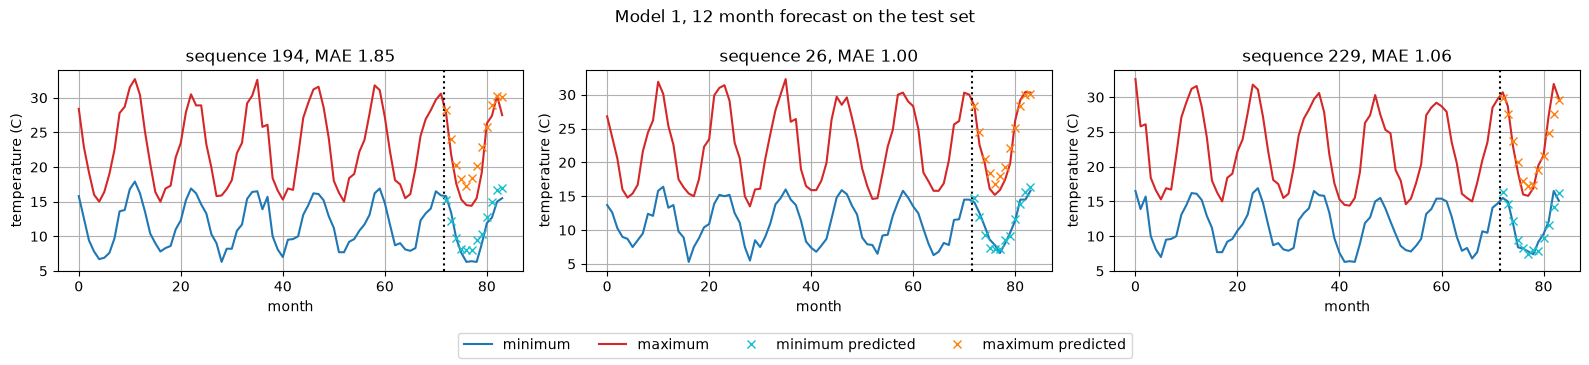

In [14]:
display_temperatures(X_test, y_test, "Model 1, 12 month forecast on the test set", y_pred=y_pred_1)

As per Section 2.1, the model reaches an MAE of 1.12 degrees on Bickley station, a station it has never been trained on. Using our ``display_temperatures`` function, we can see that the predictions gets the shape and timing of the annual cycle correct, but its curves are visibly smoother than the real ones, and sometimes the amplitude of the predictions don't match the real temperatures, which can be seen in sequence 194, where the model predicts higher temperatures throughout the winter seasons than it actually was.

## Section 3: Model 2, One-Month Forecast

In this section, we will implement the same model as Model 1 but instead predict for only one month at a time and use the model's own outputs to predict up to 12 monnths.

### Section 3.1: Architecture and Training

Model 2 is the same network with the output layer changed to a single month. We will reuse the ``build_gru_model`` function using the ``target_length`` argument to produce this model: the ``Dense`` layer drops from 24 neurons to 2 and the ``Reshape`` layer becomes 1x2 instead. We use the same training set but with the targets truncated to only the first month for training.

In [15]:
y_train_1m, y_val_1m = y_train_scaled[:, :1], y_val_scaled[:, :1]
y_test_1m = y_test[:, :1]

model_2 = build_gru_model(1)
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 72, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 72, 16)         │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1, 2)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,626 (10.26 KB)

 Trainable params: 2,626 (10.26 KB)

 Non-trainable params: 0 (0.00 B)

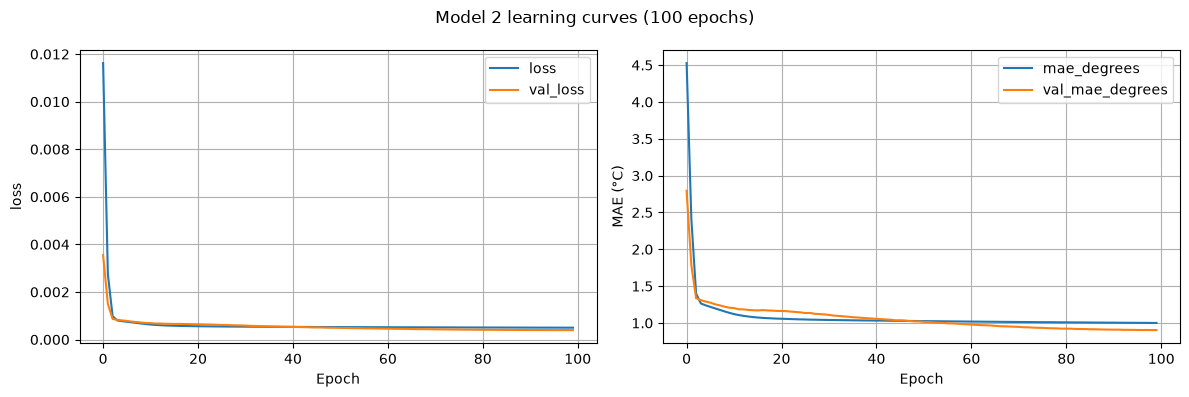

In [16]:
tf.keras.utils.set_random_seed(42)

history_2 = train_model(model_2, X_train, y_train_1m, X_val, y_val_1m)
plot_learning_curve(history_2, "Model 2 learning curves")

Evidently, predicting a single month is an easier job than predicting 12, especially with the same architecture (same 16 neurons across 2 GRU layers). The MAE starts lower and settles lower, ending at about 1.0 degrees on the training set and 0.9 on the validation set. The shape of the curves are otherwise the same as Model 1, with the validation MAE dipping below the training MAE at around epoch 50, although the validation MAE is significantly closer to the training MAE compared to Model 1. The validation loss continued to improve even by epoch 100, so this model used the full training budget and early stopping did not occur.

### Section 3.2: One-Month Test Performance

First we evaluate the model on the job it was actually trained for: predicting one month into the future.

In [17]:
y_pred_2_1m = forecast(model_2, X_test)
mae_2_1m = calculate_mae(y_test_1m, y_pred_2_1m)
print(f"Model 2 test MAE, 1 month: {mae_2_1m:.4f} C")

Model 2 test MAE, 1 month: 0.9459 C


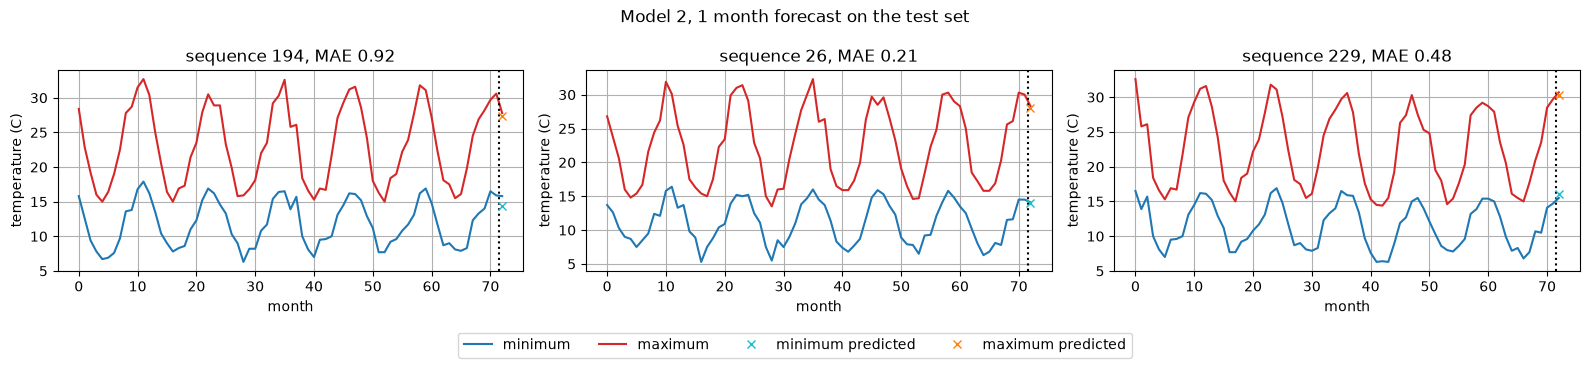

In [18]:
display_temperatures(X_test, y_test_1m, "Model 2, 1 month forecast on the test set", y_pred=y_pred_2_1m)

On the single month it was actually trained for, the model reaches 0.95 degrees on the test set. This is the lowest MAE we have seen thus far, and is to be expected as we are predicting just a single data point from 72 previous real observations.

### Section 3.3: Forecasting 12 Months with a Loop

To predict 12 months into the future, we call the model repeatedly and feed each prediction it produced back as if it were a real observation. Because the model was trained to predict one month from 72 previous months, we drop the oldest month after appending each newest prediction so that the model is always predicting from 72 observations. As such, rather than letting the window grow, we slide it, which should help to produce better predictions. 

Below, we define the ``forecast_recursively`` function that performs the above. The function reuses the ``forecast`` function defined earlier, which already returns the predictions in degrees celcius. We additionally provide a ``horizon`` argument so that we can reuse this function in Section 5 when comparing performance beyond 12 months of predictions.

In [19]:
def forecast_recursively(model, X, horizon):
    # Predict one month at a time, sliding the input window forward with each prediction
    X_window = X
    steps = []
    for _ in range(horizon):
        step = forecast(model, X_window)
        steps.append(step)
        X_window = tf.concat([X_window[:, 1:], step], axis=1)
    return tf.concat(steps, axis=1)

y_pred_2 = forecast_recursively(model_2, X_test, TARGET_LENGTH)
mae_2 = calculate_mae(y_test, y_pred_2)
print(f"Model 2 test MAE, 12 months by looping: {mae_2:.4f} °C")

Model 2 test MAE, 12 months by looping: 1.0840 °C


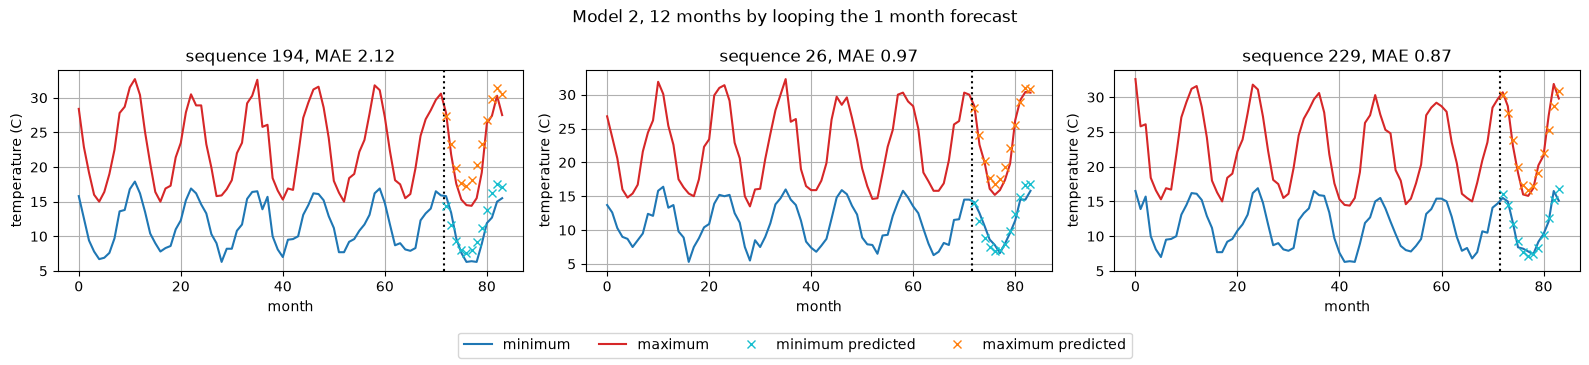

In [20]:
display_temperatures(X_test, y_test, "Model 2, 12 months by looping the 1 month forecast", y_pred=y_pred_2)

Looping Model 2 twelve times gives us 1.08 degrees MAE compared to model 1's 1.12 on exactly the same task. This is an interesting result; the loop arrangement ought to be a disadvantage as incorrect predictions can propogate into future predictions (it is reading its own predictions isntead of real observations from the second step onwards).

We can see exactly this happening in sequence 194, where the model's min/max temperature tapered off instead of continuing to decrease at around month 75, however, for the other sequences we sampled, the predictions are smooth and very close to the actual observations. The annual cycle is strong enough that even when the model is slightly wrong about one month, it barely affects the predictions on the later months. It seems tha training the model one month at a time allowed us the teach the model the same well defined task, instead of spreading its learning capability across 12 different outputs.

## Section 4: Model 3, GRU Encoder-Decoder

In this section, we will implement a GRU encoder-decoder model to predict 12 months in a looped decoder architecture.

**NOTE:** We use teacher forcing during training of this model, despite testing showing that the model actually performs slightly better without teacher forcing. This is because the project spec part (e) heavily implies using ground truth labels for training, and the textbook Chapter 16 also uses teacher forcing for the translation encoder-decoder. This also makes the comparison with Model 2 fairer as both models are trained only on real temperatures but must consume their own predictions at test time, so they face the same mismatch between training and testing.

### Section 4.1: Network Architecture

The **encoder** reuses model 1's architetecture which is just a pair of GRU layers. The first hidden layer uses ``return_sequences=True`` so that its output hidden states can be passed to the second layer as inputs. We set ``return_state=True`` for both layers so that the final hidden state of both encoder GRU layers is returned (``state_1`` and ``state_2`` respectively), while everything else is discarded.

The **decoder** is similarly a two layer stacked GRU, however, for each layer, instead of starting with an empty hidden state (zeroes), we use the two final output hidden states of the encoder to "seed" the decoder. The first decoder layer uses ``state_1`` as its initial input hidden state, and similarly, the second decoder layer uses ``state_2``. The decoder's input is the sequence it is being asked to continue. I.e. at time step 0 for the decoder, the input is the temperature at month 72 and the encoder layer 1 hidden state, which produces the prediction for month 73. During training, we use the ground truth predictions instead of the decoder's own predictions which is the normal teacher forcing setup. This is achieved using the ``shift_targets`` function defined below. On the test set, the decoder uses its own predictions otherwise it would be cheating.

The above is the regular encoder-decoder sequence-to-sequence RNN architecture. We would most likely get better performance if we passed the full sequence of hidden states of the encoder to the decoder, however, this is going into the territory of attention mechanisms, and is out of scope for this project. Additionally, the decoder's input layer is initialized with shape ``[None, 2]`` instead of a fixed length so that the trained model can be run for any number of steps (required for section 5). The same ``Rescaling`` layer is applied to both encoder and decoder inputs same as the previous models.

In [21]:
def build_encoder_decoder(n_units=16, input_length=INPUT_LENGTH, learning_rate=0.005):
    tf.keras.utils.set_random_seed(42)

    encoder_inputs = tf.keras.layers.Input(shape=[input_length, 2])
    decoder_inputs = tf.keras.layers.Input(shape=[None, 2])
    rescaling = tf.keras.layers.Rescaling(1. / SCALE)

    # Encoder: same as model 1/2
    encoder_outputs, state_1 = tf.keras.layers.GRU(n_units, return_sequences=True, return_state=True)(rescaling(encoder_inputs))
    _, state_2 = tf.keras.layers.GRU(n_units, return_state=True)(encoder_outputs)

    # Decoder: one GRU layer per encoder state
    decoder_outputs = tf.keras.layers.GRU(n_units, return_sequences=True)(rescaling(decoder_inputs), initial_state=state_1)
    decoder_outputs = tf.keras.layers.GRU(n_units, return_sequences=True)(decoder_outputs, initial_state=state_2)
    outputs = tf.keras.layers.Dense(2)(decoder_outputs)

    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=[outputs])
    model.compile(loss=tf.keras.losses.Huber(),
                  optimizer=tf.keras.optimizers.Nadam(learning_rate=learning_rate),
                  metrics=[mae_degrees])
    return model

def shift_targets(X, y):
    # Decoder inputs: last observed month + all but the last target month
    return tf.concat([X[:, -1:], y[:, :-1]], axis=1)

model_3 = build_encoder_decoder()
model_3.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 72, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, None, 2)   │          0 │ input_layer_2[0]… │
│ (Rescaling)         │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ [(None, 72, 16),  │        960 │ rescaling_2[0][0] │
│                     │ (None, 16)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_6 (GRU)         │ (None, None, 16)  │        960 │ rescaling_2[1][0… │
│                     │                   │            │ gru_4[0][1]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_5 (GRU)         │ [(None, 16),      │      1,632 │ gru_4[0][0]       │
│                     │ (None, 16)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_7 (GRU)         │ (None, None, 16)  │      1,632 │ gru_6[0][0],      │
│                     │                   │            │ gru_5[0][1]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, None, 2)   │         34 │ gru_7[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,218 (20.38 KB)

 Trainable params: 5,218 (20.38 KB)

 Non-trainable params: 0 (0.00 B)

### Section 4.2: Training

We train this model using the same ``train_model`` function we defined in Section 2.2 with the encoder and decoder inputs passed as a list. We use the ``shift_targets`` function defined above to produce the input temperatures for the decoder for teacher forcing.

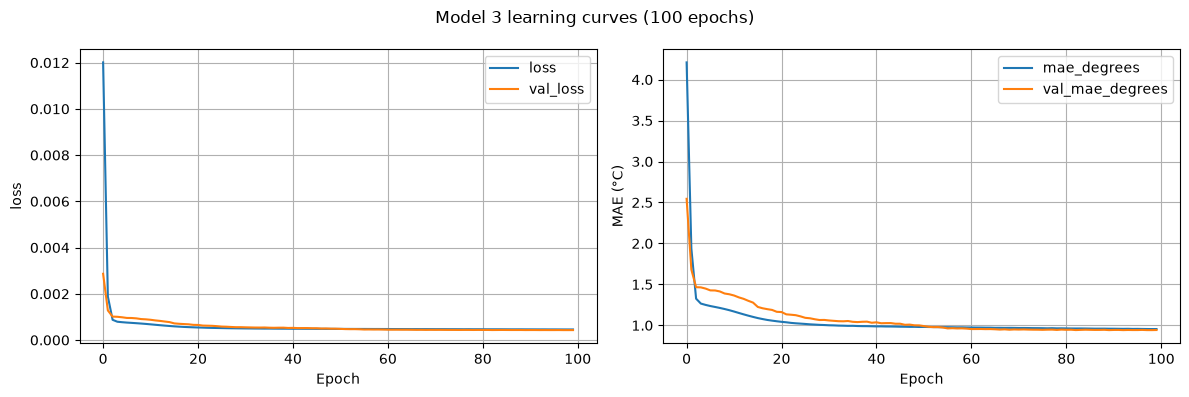

In [22]:
tf.keras.utils.set_random_seed(42)

history_3 = train_model(model_3,
                        [X_train, shift_targets(X_train, y_train)], y_train_scaled,
                        [X_val, shift_targets(X_val, y_val)], y_val_scaled)
plot_learning_curve(history_3, "Model 3 learning curves")

The encoder-decoder model trains to a validation MAE of just under 1.0 degrees, which is slightly better than model 1 on the same 12 month prediction task. The curves look healthy, and also similarly to the previous 2 models, the validation MAE dips below the training MAE at around epoch 50 interestingly.

One important note though for these plots: the validation MAE and los is measured with teacher forcing as that is how ``fit`` runs the model. The decoder is being provided the ground truth temperatures at every step, so the validation set may not be reflectively of the true test set performance (which we will see in the next).

### Section 4.3: Test Set Performance

For testing, the ground truth should not be available to the decoder, so it consumes its own output. The function defined below implements this by starting the decoder with the single last observed month, and at each iteration, we append its predictions to the decoder input to ensure everything after the first month was generated from predicted values only.

Note that the below code would rerun the encoder at every pass when we call ``model()`` however the number of passes is small and it allows us to avoid having a separate inference model.

In [23]:
def forecast_encoder_decoder(model, X, horizon):
    # Grow the decoder input one month at a time out of the model's own predictions
    decoder_inputs = X[:, -1:]
    for _ in range(horizon):
        y_pred = model([X, decoder_inputs], training=False) * SCALE
        decoder_inputs = tf.concat([X[:, -1:], y_pred], axis=1)
    return y_pred

y_pred_3 = forecast_encoder_decoder(model_3, X_test, TARGET_LENGTH)
mae_3 = calculate_mae(y_test, y_pred_3)
print(f"Model 3 test MAE, 12 months autoregressive: {mae_3:.4f} °C")

Model 3 test MAE, 12 months autoregressive: 1.2075 °C


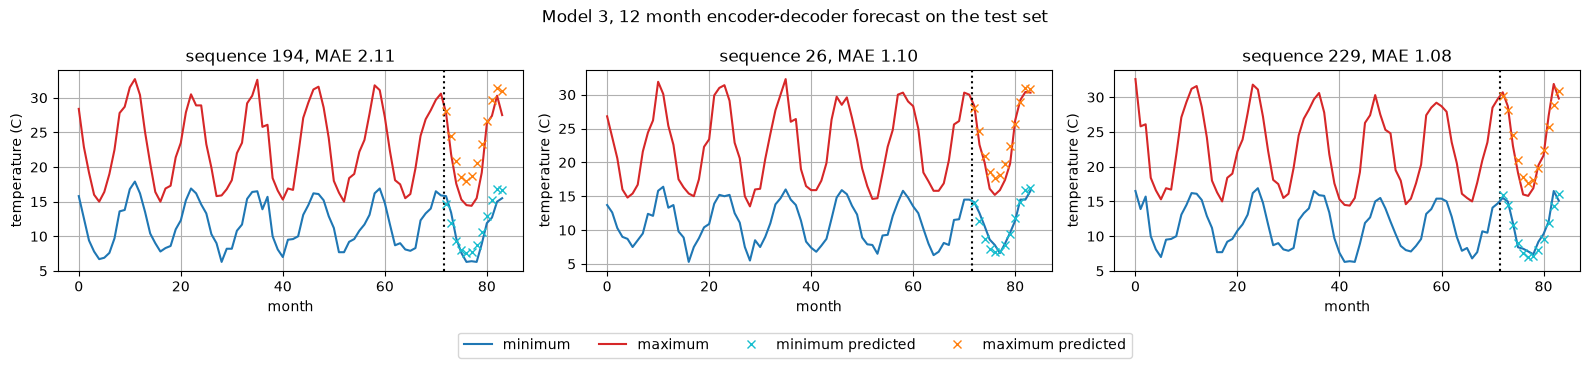

In [24]:
display_temperatures(X_test, y_test, "Model 3, 12 month encoder-decoder forecast on the test set", y_pred=y_pred_3)

Model 3 reaches a test MAE of 1.21C which is the worst of the three models. The sampled sequences look much like those of the other two models, with the same smooth seasonal template and the same errors on sequence 194. The plots do however show the problem we expected from Model 2 but did not see clearly there: a wrong prediction propagating into later predictions. We can see this in sequence 229, where the maximum temperature predictions start to go wrong at around month 77, and every later prediction is shifted to the right resulting in the forecast temperature rising later than the real one.

The difference in MAE between the validation and test MAE is likely exposure bias, since the validation MAE was measured with teacher forcing while the test MAE was not. On the test set, we can evidently see that incorrect predictions at one time step propagated into future predictions. However, the difference in MAE could also be due to differences in the specific station climates. Model 1 has no decoder and similarly performs worse on the Bickley test set than on the Swanbourne validation set. Separating the two effects would require evaluating both decoding modes on the same station, which is outside the scope of this project, so we do not investigate it further here.

## Section 5: Comparing Prediction Horizons

Both Models 2 and 3 generate forecasts one month at a time using its own predictions as inputs. As a result, neither model needs retraining to predict further ahead. We will reuse the model specific forecasting functions defined in Sections 3 and 4 to predict up to 24 months into the future using the horizon argument. We will predict for 12, 15, 18, 21 and 24 months into the future, and as an additional reference point, we also include a forecast that involves no learning. ``seasonal_naive`` simply repeats the last 12 months, repeated for whatever horizon is asked for. This serves as a useful baseline as temperature is almost perfectly annual, and for a predictive model, it should beating a naive pattern, and is also testing if the models actually learned patterns in the data rather than just lower MAEs.

In [ ]:
def seasonal_naive(X, horizon):
    # Reference forecast: repeat the last 12 observed months
    last_year = X[:, -12:]
    n_years = -(-horizon // 12) 
    repeated = tf.tile(last_year, [1, n_years, 1])
    return repeated[:, :horizon]

horizons = [12, 15, 18, 21, 24]
rows = []
# Calculate MAE for all 2 models + naive model for all horizons
for horizon in horizons:
    _, y_true = split_sequences(test_seq, INPUT_LENGTH, horizon)
    rows.append({
        "horizon": horizon,
        "model 2 (looped)": calculate_mae(y_true, forecast_recursively(model_2, X_test, horizon)),
        "model 3 (encoder-decoder)": calculate_mae(y_true, forecast_encoder_decoder(model_3, X_test, horizon)),
        "seasonal naive": calculate_mae(y_true, seasonal_naive(X_test, horizon)),
    })

horizon_mae = pd.DataFrame(rows).set_index("horizon")
horizon_mae.round(4)

,model 2 (looped),model 3 (encoder-decoder),seasonal naive
horizon,,,
12,1.0840,1.2075,1.2350
15,1.0938,1.2215,1.2327
18,1.1056,1.2486,1.2314
21,1.1166,1.2781,1.2320
24,1.1255,1.2964,1.2338


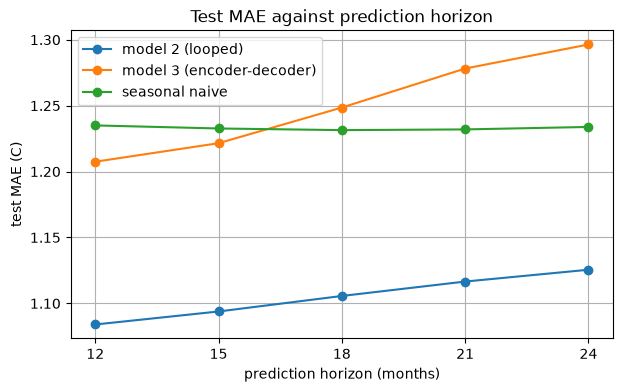

In [26]:
horizon_mae.plot(marker="o", grid=True, figsize=(7, 4),
                 xlabel="prediction horizon (months)", ylabel="test MAE (C)",
                 title="Test MAE against prediction horizon")
plt.xticks(horizons)
plt.show()

**Which model deteriorates fastest.** Model 3, by roughtly a factor of 2 compared to model 2. Going from 12 to 24 month horizon, Model 3's MAE climbs about 0.089 C while model 2 climbs by only about 0.042. Model 2 consistently outperforms Model 3 at every prediction horizon as well. This isn't exactly surprising, as we already the propogation of prediction errors in our model 3 evaluation in Section 4.3. In addition, Model 3's decoder was trained for 12 step sequences, and was never trained/asked for more. Here, we are asking for double the predictions into the future compared to what the model is familiar with, so the rapidly deteriorating performance is to be expected after 12 months as every step past that point is unfamiliar territory. In constrast, Model 2 also has no sense of position, as it is just predicting a single month every iteration, so iterating 24 times instead of 12 isn't a new task.

**How good is the transfer from one station to another?** Good enough to be useful, particularly for model 2. On the easier on month task for model 2, it reaches about 1.0 C MAE on the training station, 0.90 C on Swanbourne and 0.95 C for Bickley. The performance on the two unseen stations is no worse (if not slightly better) than the 3 stations it was trained on. Model 3 similarly finishes training at about 0.95 C MAE but reaches 1.21 C MAE on Bickley, although this gap overstates the transfer loss since the training (and validation) MAE was measured with teacher forcing while the test MAE was not. Model 2's performance isn't as impressive as it sounds, because every prediction uses the previous 72 months of Bickley/Swanbourne's own history of input, so the station's "climate" (level and seasonal amplitude) can be read straight off this data. What does transfer between the stations is the general shape of WA's annual temperature cycle and the shape is similar enuogh between stations that it can be reused. 

**Comparison with a seasonal naive baseline.** The seasonal naive forecast scores consistently at ~1.23 C MAE between the 12 and 24 month horizon because it exploits the annual period exactly, so it won't degrade. Model 2 performs better than the naive forecast at every horizon but only by about 0.1-0.15 C. Model 3 however, effectively ties with the naive forecast between months 12-15 and deteriorates so much that it performs worse than the naive forecast past the 15 month mark. Both models have learned the annual cycle well, however, it is difficult to predict noise or anomalies that can occur year to year, as there may be factors that lead to exceptional variation in temperature in a following year that simply isn't present in the past 72 months of data.

## Section 6: Variational Autoencoder

In this section we will design and train a VAE to try generate convincing looking maximum temperatures.

### Section 6.1: Data Preparation

For the VAE, we input the full 84 month sequences from ``train_seq`` with only the maximum temperatures, which gives a flat vector of 84 numbers per sequence. We similarly use the maximum temperatures from ``val_seq`` for the validation set, and scale both with the same ``SCALE`` constant used for the forecasting models. Scaling is significantly more important for a VAE, because its loss is the sum of an MSE reconstruction loss and a KL divergence latent loss, which penalises the codings distribution for straying from a standard gaussian. If the inputs are left in degrees, the reconstruction loss becomes very large while the latent loss stays small, so the latent loss is effectively ignored. The codings then do not follow a standard Gaussian, and sampling from such a distribution to generate new sequences will produce poor results.

In [27]:
CODINGS_SIZE = 8
LATENT_WEIGHT = 0.1

T_train = train_seq[:, :, 1] / SCALE
T_val = val_seq[:, :, 1] / SCALE

print(f"T_train: {T_train.shape}  T_val: {T_val.shape}")
print(f"scaled range: {float(tf.reduce_min(T_train)):.3f} - {float(tf.reduce_max(T_train)):.3f}")

T_train: (1522, 84)  T_val: (313, 84)
scaled range: 0.405 - 0.907


### Section 6.2: Model Architecture

We will reuse the Dense VAE architecture in Chapter 17 of Geron's textbook. The encoder is 2 dense layers of 64 and 32 neurons respectively. Then, two parallel dense layers produce the mean and log variance of the codings distribution. Finally, a ``Sampling`` layer draws a codings vector from the distribution using the reparameterisation trick. The decoder mirrors the encoder to produce 84 values, with a linear output layer as in the textbook, since it is predicting scaled temperatures rather than probabilities. We use a coding size of 8 as a maximum temperature sequence is similar to a sine wave with only a few parameters required to represent such a function (station's mean level, amplitude etc.). 8 dimensions should be plenty to represent these features without being so wide that the encoder can memorise sequences outright.

Geron divides the latent loss by 784 because Keras's mse averages reconstruction error over 784 pixels instead of summing. The equivalent here would be to divide by 84 (for 84 months), but on our data the latent loss after dividing by 84 is still too strong relative to the reconstruction loss, resulting in the model just generating a flat line. The reason for this is the scale of our data: our scaled temperatures has a variance of about 0.016, which is around 7 times smaller Fashion MNIST (about 0.12). The model always has the option of ignoring its input and outputting the average sequence, which gives a reconstruction loss equal to the data's variance. Encoding each sequence can therefore lower the reconstruction loss by at most 0.016 on our data, compared with about 0.12 for Fashion MNIST, while latent loss does not depend on the data's scale. We therefore introduce a hyperparameter ``LATENT_WEIGHT`` which is a factor applied to the latent loss on top of the division by 84, to scale down the latent loss further. Through some testing, we found that anything between 0.02=0.2 gave gave realistic samples with reconstruction errors between 1.2 and 1.8 C. As such, we use 0.1 which is in the middle of working range. 

In [28]:
class Sampling(tf.keras.layers.Layer):
    def __init__(self, sequence_length, latent_weight, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.latent_weight = latent_weight

    def call(self, inputs):
        mean, log_var = inputs
        # Latent loss, normalised by the sequence length and reweighted
        latent_loss = -0.5 * tf.reduce_sum(
            1 + log_var - tf.exp(log_var) - tf.square(mean), axis=-1)
        # Multiply by latent weight factor
        self.add_loss(self.latent_weight * tf.reduce_mean(latent_loss) / self.sequence_length)
        return tf.random.normal(tf.shape(log_var)) * tf.exp(log_var / 2) + mean

def build_vae(codings_size=CODINGS_SIZE, latent_weight=LATENT_WEIGHT, 
              n_units=(64, 32), learning_rate=1e-3):
    tf.keras.utils.set_random_seed(42)

    # Produce the codings
    inputs = tf.keras.layers.Input(shape=[84])
    Z = tf.keras.layers.Dense(n_units[0], activation="relu")(inputs)
    Z = tf.keras.layers.Dense(n_units[1], activation="relu")(Z)
    codings_mean = tf.keras.layers.Dense(codings_size)(Z)
    codings_log_var = tf.keras.layers.Dense(codings_size)(Z)
    codings = Sampling(84, latent_weight)([codings_mean, codings_log_var])
    encoder = tf.keras.Model(inputs=[inputs], outputs=[codings_mean, codings_log_var, codings])

    # Reconstruct inputs
    decoder_inputs = tf.keras.layers.Input(shape=[codings_size])
    x = tf.keras.layers.Dense(n_units[1], activation="relu")(decoder_inputs)
    x = tf.keras.layers.Dense(n_units[0], activation="relu")(x)
    outputs = tf.keras.layers.Dense(84)(x)
    decoder = tf.keras.Model(inputs=[decoder_inputs], outputs=[outputs])

    _, _, codings = encoder(inputs)
    vae = tf.keras.Model(inputs=[inputs], outputs=[decoder(codings)])

    vae.compile(loss="mse", optimizer=tf.keras.optimizers.Nadam(learning_rate=learning_rate),
                metrics=[mae_degrees])
    return vae, encoder, decoder

vae, variational_encoder, variational_decoder = build_vae()
vae.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_3 (Functional)       │ [(None, 8), (None, 8), │         8,048 │
│                                 │ (None, 8)]             │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_4 (Functional)       │ (None, 84)             │         7,860 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,908 (62.14 KB)

 Trainable params: 15,908 (62.14 KB)

 Non-trainable params: 0 (0.00 B)

### Section 6.3: Training

We train the VAE to reconstruct its own input for 100 epochs with early stopping on the validation loss. The reconstruction MAE in the right panel shows how closely the model can reproduce a real sequence it was shown, which is a good check to show that training went well but doesn't necessarily guarantee the sequences it generates will look plausible.

I0000 00:00:1790223895.424116  138892 service.cc:153] XLA service 0x79156d101220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790223895.424148  138892 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 13.3.0; Toolkit: 13.0.0; DNN: 9.23.1)
I0000 00:00:1790223895.446689  138892 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790223895.587526  138892 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_151645__.15


I0000 00:00:1790223898.160974  138892 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1790223898.359586  138892 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_151645__.15


I0000 00:00:1790223900.975472  138886 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_152165__.7


I0000 00:00:1790223901.463110  138892 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_152165__.7


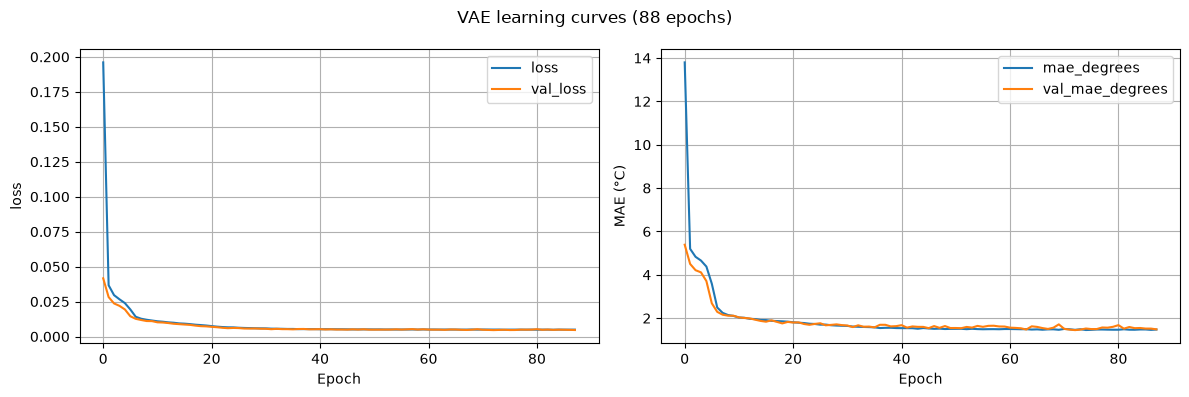

In [29]:
tf.keras.utils.set_random_seed(42)

early_stopping = tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)
history_vae = vae.fit(T_train, T_train, epochs=100, batch_size=32,
                      validation_data=(T_val, T_val),
                      callbacks=[early_stopping], verbose=0)
plot_learning_curve(history_vae, "VAE learning curves")

Here we can see that the reconstruction MAE falls to about 1.5 degrees and the training and validation curves sit almost identically on top of each other the whole run. Training stopped at epoch 88 indicating that further training may have caused the model to overfit.

### Section 6.4: Synthesizing Sequences

To generate new sequences, we skip the encoder and draw coding vectors from the distribution of the codings directly, push them through the decoder, then multiply by ``SCALE`` to get the output back to degrees celsius.

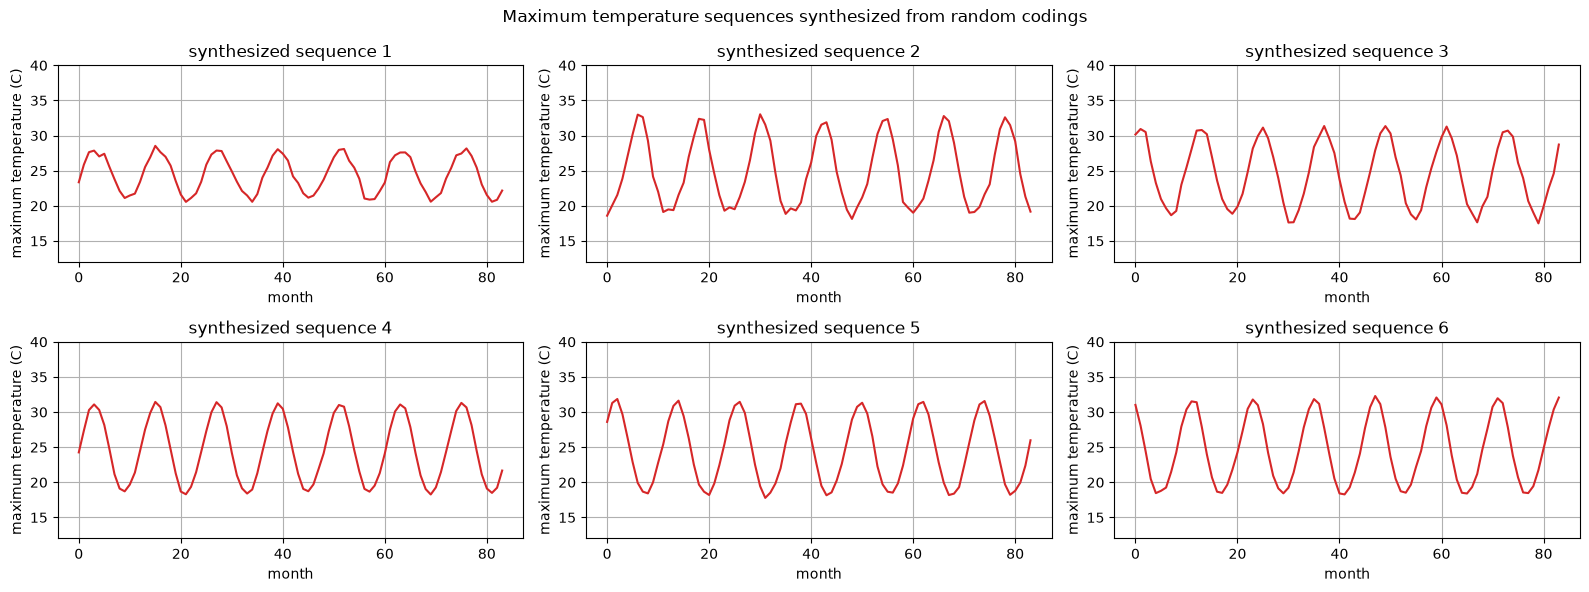

In [30]:
tf.keras.utils.set_random_seed(42)

codings = tf.random.normal(shape=[6, CODINGS_SIZE])
synthesized = variational_decoder(codings) * SCALE

plt.figure(figsize=(16, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.plot(np.arange(84), synthesized[i], color="tab:red")
    plt.title(f"synthesized sequence {i + 1}")
    plt.xlabel("month")
    plt.ylabel("maximum temperature (C)")
    plt.ylim(12, 40)
    plt.grid(True)
plt.suptitle("Maximum temperature sequences synthesized from random codings")
plt.tight_layout()
plt.show()

For comparison, here are six real maximum temperature sequences from the training set drawn on the same axes.

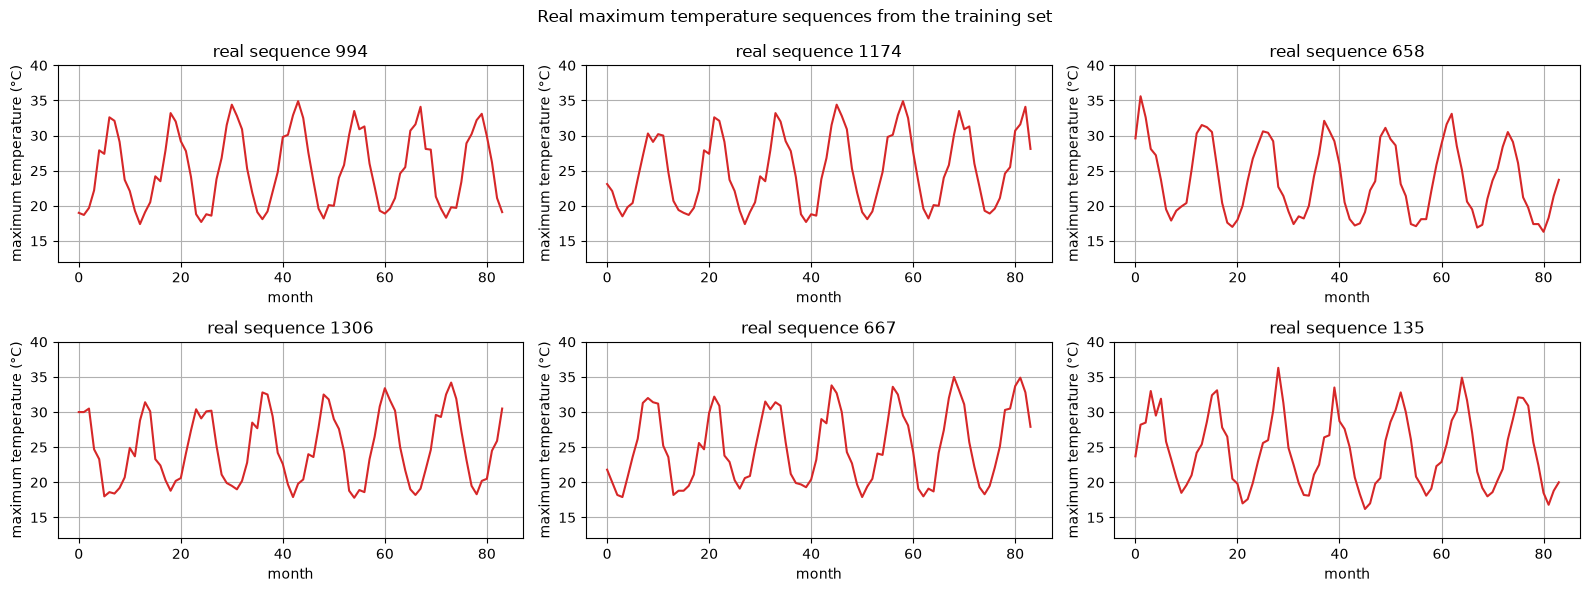

In [31]:
rng = np.random.default_rng(42)
real_indices = rng.choice(train_seq.shape[0], size=6, replace=False)

plt.figure(figsize=(16, 6))
for i, index in enumerate(real_indices):
    plt.subplot(2, 3, i + 1)
    plt.plot(np.arange(84), train_seq[index, :, 1], color="tab:red")
    plt.title(f"real sequence {index}")
    plt.xlabel("month")
    plt.ylabel("maximum temperature (°C)")
    plt.ylim(12, 40)
    plt.grid(True)
plt.suptitle("Real maximum temperature sequences from the training set")
plt.tight_layout()
plt.show()

We further compare a few summary statistics of 300 synthesized sequences against the real training sequences. Namely, the mean monthly change and mean peak to trough range can tell us whether the curve is as as smooth as a real temperature record and whether the seasnonal pattern surved respectively.

In [32]:
def sequence_stats(sequences):
    # Function to calculate the 4 stats for a set of sequences, reused for real/synthesized set
    return {
        "mean": float(tf.reduce_mean(sequences)),
        "std": float(tf.math.reduce_std(sequences)),
        "mean monthly change": float(tf.reduce_mean(tf.abs(sequences[:, 1:] - sequences[:, :-1]))),
        "mean peak to trough": float(tf.reduce_mean(
            tf.reduce_max(sequences, axis=1) - tf.reduce_min(sequences, axis=1))),
    }

tf.random.set_seed(42)
many_codings = tf.random.normal(shape=[300, CODINGS_SIZE])

pd.DataFrame({
    "real": sequence_stats(train_seq[:, :, 1]),
    "synthesized": sequence_stats(variational_decoder(many_codings) * SCALE),
}).round(2)

,real,synthesized
mean,24.70,24.72
std,5.11,4.42
mean monthly change,2.48,2.02
mean peak to trough,17.24,12.83


**Do they look realistic? Mostly.** All six generated sequences have a clean annual cycle with 7 reptitions across the 84 months. The peaks and troughs mostly reflect what we would expect (excluding the first generated sequence, whose amplitude is significantly smaller than real temperatures). The differences in level, amplitude and in which calendar month they start on tells us that the codings are actually carrying properties of the temperature sequences rather than the decoder having memorised one sequence.

The problem however is that the sequences are too smooth in comparison to real sequences which generally contain fairly "jagged" temperatures. This can be seen in the summary statistics above. The mean is almost exact at 24.72 vs 24.70, so the synthesized sequences gets the overall climate correct, but the mean month to month change is 2.02 compared to 2.48 for real sequences. In addition, the mean peak to trough range is 12.83 compared to 17.24 for real sequences. These statistics can be seen in the plots, where real sequences are visibly "jagged" with a warm month interrupting a cooling trend (this can be seen in most real sequences) and whole years that are clearly hotter or colder than their neighbours (Sequence 658, 135). In contrast, the synthesized curves are closer to pure sinusoids that repeat almost identically year by year.

This is mostly expected behaviour, as the VAE is trained on sequare error reconstruction loss. For any month whose weather noise the model struggles to reconstruct, the option is to minimise squared error and predict the average while leaving this noise out. This results in the very close mean temperature we see in the summary statistics above, while the mean monthly change and peak to trough and signifincantly lower than real sequences. This failure mode is especially illustrated in the first sequence we generated.

## Section 7: Summary and Conclusion

In this project we forecasted monthly mean minimum and maximum temperatures at one weather station using models trained on three others, then trained a VAE to generate maximum temperature sequences. Provided below is a breif summary of this project: 

| model | task | test MAE (C) |
|---|---|---|
| model 1 | 12 months in one go | 1.125 |
| model 2 | 1 month | 0.946 |
| model 2 | 12 months by looping | 1.084 |
| model 3 | 12 months, encoder-decoder | 1.208 |
| seasonal naive | 12 months, no learning at all | 1.235 |

**Forecasting models.** We trained three GRU-based models to forecast 12 months of minimum and maximum temperatures: a direct 12 month forecast, a looped one month forecast, and an encoder-decoder. The main problem we ran into was that the default ``tanh`` activation saturated on unscaled temperatures, leaving the network no better than a constant forecast. Dividing the data by a single constant fixed this. The looped model (Model 2) performed best, while the encoder-decoder performed worst and degraded fastest over longer horizons, likely because it was trained on ground truth inputs but has to consume its own predictions at test time. All three models transferred reasonably well to an unseen station, but only modestly beat the seasonal naive baseline, meaning most of what they learned is just the annual cycle (mean and amplitudes).

**Variational autoencoder.** We trained a Dense VAE to synthesize maximum temperature sequences. The main problem was balancing its two loss terms: carrying over the textbook's latent loss normalisation directly caused the codings to collapse, producing the same near flat line for every sample because our data has a much lower variance compared to image pixels. Reducing the weight of the latent loss fixed this, and the resulting samples look like fairly realistic temperature records, although they are noticeably smoother and flatter than real ones.

**Conclusion.** Overall, the simplest approaches held up best for predicting future temperatures. The encoder-decoder's weakness may reflect the task rather than the architecture itself, as encoder-decoders are generally for outputs that differ in kind from the input, such as translation, whereas in our case, the output is mostly a continuation of the same series. Likewise, the VAE showed that settings that work on images do not automatically carry over to data at a different scale (our VAE reused the Fashion MNIST image generation architecture). In both cases, the results depended less on the model's complexity and more on how well its assumptions matched the data.